In [3]:
from pathlib import Path

DATASET_DIR = Path("../../data/minecraft_mobs-2/yolo/")

for item in DATASET_DIR.iterdir():
    print(item.name)

data.yaml
test
train
val


In [4]:
import yaml

with open(DATASET_DIR / "data.yaml", "r") as f:
    data = yaml.safe_load(f)

data

{'train': 'train/images',
 'val': 'val/images',
 'test': 'test/images',
 'nc': 87,
 'names': {0: 'blaze',
  1: 'bogged',
  2: 'breeze',
  3: 'cave_spider',
  4: 'creaking',
  5: 'creeper',
  6: 'drowned',
  7: 'elder_guardian',
  8: 'enderman',
  9: 'endermite',
  10: 'evoker',
  11: 'ghast',
  12: 'guardian',
  13: 'hoglin',
  14: 'husk',
  15: 'illusioner',
  16: 'magma_cube',
  17: 'parched',
  18: 'phantom',
  19: 'piglin',
  20: 'piglin_brute',
  21: 'pillager',
  22: 'ravager',
  23: 'shulker',
  24: 'silverfish',
  25: 'skeleton',
  26: 'slime',
  27: 'spider',
  28: 'stray',
  29: 'vex',
  30: 'vindicator',
  31: 'warden',
  32: 'witch',
  33: 'wither_skeleton',
  34: 'zoglin',
  35: 'zombie',
  36: 'zombie_villager',
  37: 'zombified_piglin',
  38: 'bee',
  39: 'dolphin',
  40: 'goat',
  41: 'iron_golem',
  42: 'llama',
  43: 'panda',
  44: 'polar_bear',
  45: 'strider',
  46: 'trader_llama',
  47: 'wolf',
  48: 'allay',
  49: 'armadillo',
  50: 'axolotl',
  51: 'bat',
  52: '

In [5]:
print("Number of classes:", data["nc"])

print("\nClasses:")
for i, cls in enumerate(data["names"]):
    print(f"{i}: {cls}")

Número de classes: 87

Classes:
0: 0
1: 1
2: 2
3: 3
4: 4
5: 5
6: 6
7: 7
8: 8
9: 9
10: 10
11: 11
12: 12
13: 13
14: 14
15: 15
16: 16
17: 17
18: 18
19: 19
20: 20
21: 21
22: 22
23: 23
24: 24
25: 25
26: 26
27: 27
28: 28
29: 29
30: 30
31: 31
32: 32
33: 33
34: 34
35: 35
36: 36
37: 37
38: 38
39: 39
40: 40
41: 41
42: 42
43: 43
44: 44
45: 45
46: 46
47: 47
48: 48
49: 49
50: 50
51: 51
52: 52
53: 53
54: 54
55: 55
56: 56
57: 57
58: 58
59: 59
60: 60
61: 61
62: 62
63: 63
64: 64
65: 65
66: 66
67: 67
68: 68
69: 69
70: 70
71: 71
72: 72
73: 73
74: 74
75: 75
76: 76
77: 77
78: 78
79: 79
80: 80
81: 81
82: 82
83: 83
84: 84
85: 85
86: 86


In [6]:
from pathlib import Path

def count_images(folder):
    exts = [".jpg", ".jpeg", ".png"]

    return sum(
        1
        for f in folder.rglob("*")
        if f.suffix.lower() in exts
    )

In [9]:
for split in ["train", "val", "test"]:
    n = count_images(DATASET_DIR / split / "images")
    print(split, n)

train 21846
val 2730
test 2730


In [10]:
def count_labels(folder):
    return len(list(folder.glob("*.txt")))

In [11]:
for split in ["train", "val"]:
    n = count_labels(DATASET_DIR / split / "labels")
    print(split, n)

train 21846
val 2730


We have the same number of labels and images!

In [12]:
images_dir = DATASET_DIR / "train" / "images"
labels_dir = DATASET_DIR / "train" / "labels"

missing = []

for img in images_dir.glob("*"):
    label = labels_dir / f"{img.stem}.txt"

    if not label.exists():
        missing.append(img.name)

print("Images without label:", len(missing))

Imagens sem label: 0


In [13]:
from collections import Counter

counter = Counter()

for split in ["train", "valid", "test"]:

    labels_path = DATASET_DIR / split / "labels"

    for file in labels_path.glob("*.txt"):

        with open(file) as f:

            for line in f:

                cls = int(line.split()[0])

                counter[cls] += 1

In [ ]:
import pandas as pd

df = pd.DataFrame({
    "class_id": counter.keys(),
    "count": counter.values()
})

df["class_name"] = df["class_id"].map(
    lambda x: data["names"][x]
)

df.sort_values(
    "count",
    ascending=False
)

c:\Users\pedro\anaconda3\envs\visao-computacional\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


,class_id,count,class_name
1,3,708,zombie
0,1,622,skeleton
3,2,361,spider
2,0,293,creeper


In [14]:
import matplotlib.pyplot as plt

df = df.sort_values("count", ascending=False)

plt.figure(figsize=(12,5))

plt.bar(
    df["class_name"],
    df["count"]
)

plt.xticks(rotation=45)

plt.title("Class Distribution")

plt.show()

NameError: name 'df' is not defined

In [34]:
import random
import cv2
import matplotlib.pyplot as plt

images = list(
    (DATASET_DIR/"train"/"images").glob("*")
)

sample = random.sample(images, 9)

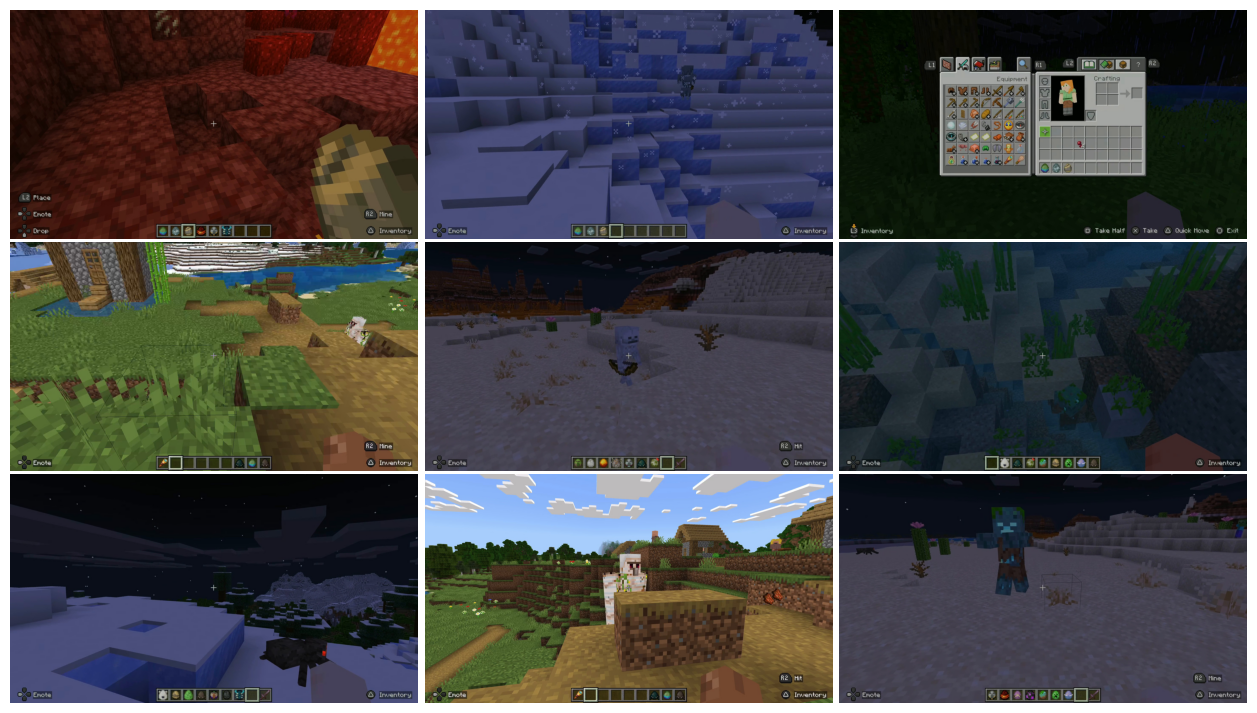

In [36]:
fig, axes = plt.subplots(
    3, 3,
    figsize=(16, 9),
    gridspec_kw={"wspace": 0.01, "hspace": 0.01}
)

for ax, img_path in zip(axes.ravel(), sample):

    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    ax.imshow(img)
    ax.axis("off")

plt.show()